# Reconhecimento de 10 Dígitos com o Perceptron

### Trabalho 04 — Disciplina de Redes Neurais

---

Uma rede de **100 entradas** e **10 neurônios**, treinada com o algoritmo mais
antigo que existe em redes neurais — e ainda assim capaz de reconhecer os dez
dígitos mesmo com 1 em cada 5 pixels trocado.

## Roteiro

1. O problema — dez dígitos numa matriz 10×10
2. O algoritmo do perceptron
3. Treinar e ver convergir
4. O que a rede aprendeu
5. Análise de ruído
6. **Demonstração**

## 1. O problema

In [1]:
import sys, pathlib
RAIZ = pathlib.Path.cwd()
if not (RAIZ / "perceptron.py").exists():
    RAIZ = RAIZ.parent          # caso o notebook esteja numa subpasta
sys.path.insert(0, str(RAIZ))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from perceptron import (Perceptron, carregar_digitos, para_imagem,
                        adicionar_ruido, testar_com_ruido, DIGITOS, LADO)

X, T, rotulos = carregar_digitos()
print(f"X: {X.shape}  ->  {X.shape[0]} digitos de {X.shape[1]} pixels")
print(f"T: {T.shape}  ->  o alvo de cada digito\n")
print("O digito 3, como esta escrito no codigo:")
print("\n".join(DIGITOS[3]))

X: (10, 100)  ->  10 digitos de 100 pixels
T: (10, 10)  ->  o alvo de cada digito

O digito 3, como esta escrito no codigo:
.########.
.......##.
......##..
.....##...
...#####..
.......##.
........##
##......##
.##....##.
..######..


### Por que **bipolar** e não binário?

Cada pixel vale **+1 (aceso)** ou **−1 (apagado)** — e não 0 e 1.

Motivo: na regra de correção o ajuste é proporcional a $x_i$. Se o pixel
apagado valesse **zero**, ele nunca contribuiria com nada — a *ausência de
tinta deixaria de ser informação*. Com −1, os dois estados pesam igual.

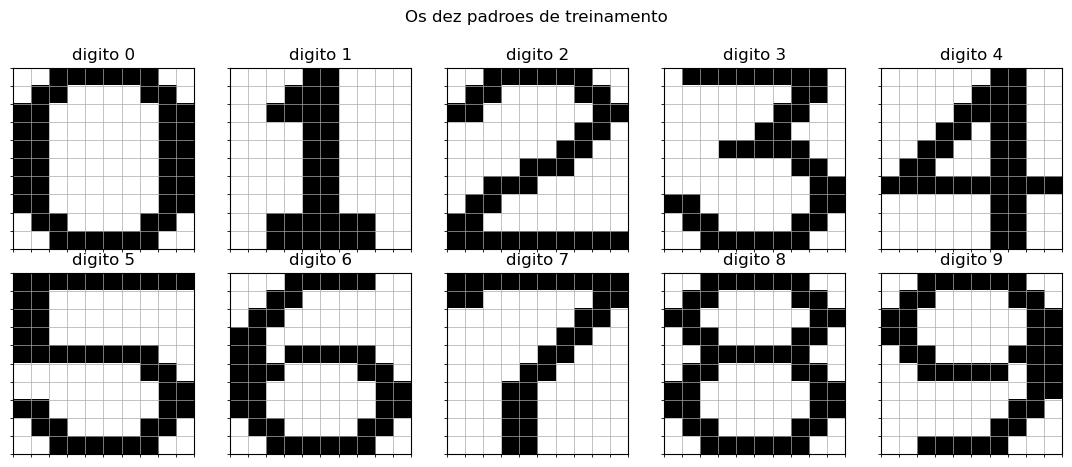

In [2]:
fig, eixos = plt.subplots(2, 5, figsize=(11, 4.6))
for k, ax in zip(rotulos, eixos.ravel()):
    ax.imshow(para_imagem(X[k]), cmap="gray_r", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(-0.5, LADO, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, LADO, 1), minor=True)
    ax.grid(which="minor", color="#aaa", lw=0.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"digito {k}")
fig.suptitle("Os dez padroes de treinamento", y=1.0)
fig.tight_layout(); plt.show()

## 2. O algoritmo do perceptron

**Propagação** — cada neurônio $j$ soma suas 100 entradas:

$$y\_in_j = b_j + \sum_{i=1}^{100} x_i w_{ij}
\qquad
y_j = \begin{cases} +1, & y\_in_j \ge 0\\ -1, & \text{senão}\end{cases}$$

**Correção** — só mexe nos pesos **onde errou**:

$$\text{se } t_j \neq y_j: \quad b_j \mathrel{+}= \alpha t_j
\qquad w_{ij} \mathrel{+}= \alpha t_j x_i$$

**Parada** — quando uma época inteira passa sem nenhuma correção.

> Não há camada oculta, nem gradiente, nem retropropagação.
> São 10 problemas binários independentes rodando lado a lado.

In [3]:
import inspect
print(inspect.getsource(Perceptron.treinar_uma_epoca))

    def treinar_uma_epoca(self, X, T):
        """
        Executa UMA epoca (uma passada por todos os padroes).

        Retorna quantas atualizacoes de peso foram feitas. Zero significa
        que a rede convergiu.
        """
        n_atualizacoes = 0

        for k in range(len(X)):          # Passo 2
            x = X[k]                     # Passo 3
            t = T[k]

            y_in = self.b + x @ self.W   # Passo 4
            y = self.ativacao(y_in)

            errou = y != t               # Passo 5: so corrige onde errou
            if errou.any():
                correcao = self.alfa * t * errou
                self.W += np.outer(x, correcao)
                self.b += correcao
                n_atualizacoes += int(errou.sum())

        return n_atualizacoes



## 3. Treinar

In [4]:
rede = Perceptron(alfa=1.0, limiar=0.0)
epocas = rede.treinar(X, T)
print(f"\nAcuracia nos digitos originais: {rede.acuracia(X, rotulos):.0%}")

 epoca |  atualizacoes |  acertos
----------------------------------
     1 |            39 |      7/10
     2 |            10 |     10/10
     3 |             4 |     10/10
     4 |             0 |     10/10
----------------------------------
Convergiu na epoca 4: nenhum peso mudou.

Acuracia nos digitos originais: 100%


### O detalhe que sempre gera pergunta

Na **época 2** a rede já acerta 10 de 10. Mas o treino continua até a **4**.

Os dois critérios são diferentes:

- **acerto** = o neurônio vencedor é o certo;
- **o algoritmo** exige que *cada um* dos 10 neurônios dê exatamente o valor
  esperado.

Um dígito pode ser classificado certo e ainda assim gerar correção, porque
algum neurônio de outra classe respondeu +1 quando devia responder −1.

**As épocas extras não aumentam o acerto — aumentam a folga.** E é essa folga
que vira resistência a ruído.

## 4. O que a rede aprendeu

Cada neurônio tem 100 pesos, um por pixel. Reorganizando de volta em 10×10,
dá para **ver** o que ele aprendeu.

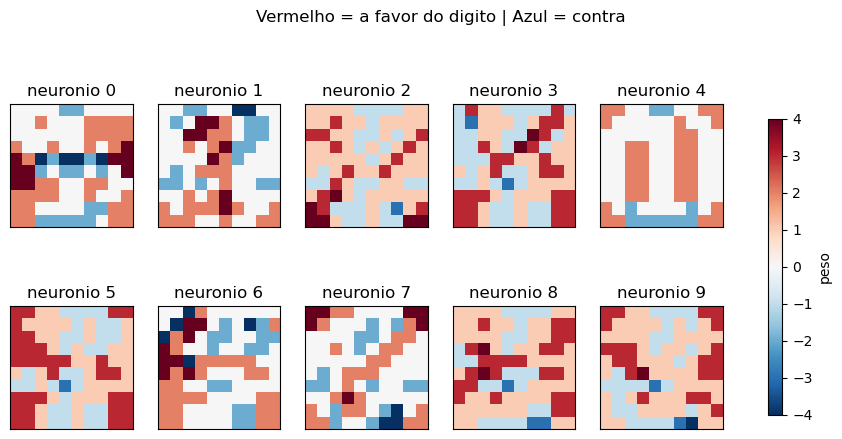

In [5]:
vmax = float(np.percentile(np.abs(rede.W), 98))
fig, eixos = plt.subplots(2, 5, figsize=(11.5, 4.8))
for j, ax in enumerate(eixos.ravel()):
    im = ax.imshow(rede.mapa_de_pesos(j), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"neuronio {j}")
fig.colorbar(im, ax=eixos, shrink=0.8, label="peso")
fig.suptitle("Vermelho = a favor do digito | Azul = contra", y=1.03)
plt.show()

Dá para reconhecer os moldes: o **1** na coluna central do neurônio 1,
a diagonal do **7**, o anel do **0**.

**Por quê?** A regra soma o próprio padrão de entrada aos pesos a cada
correção. O vetor de pesos acaba sendo uma combinação dos dígitos de treino —
funciona como um **molde** (*template*).

Essa transparência é uma vantagem didática que se perde nas redes profundas.

## 5. Análise de ruído

Cada pixel é invertido com probabilidade $p$ (sal-e-pimenta bipolar).

- $p = 0{,}10$ → em média 10 dos 100 pixels trocados
- $p = 0{,}50$ → a imagem vira ruído puro

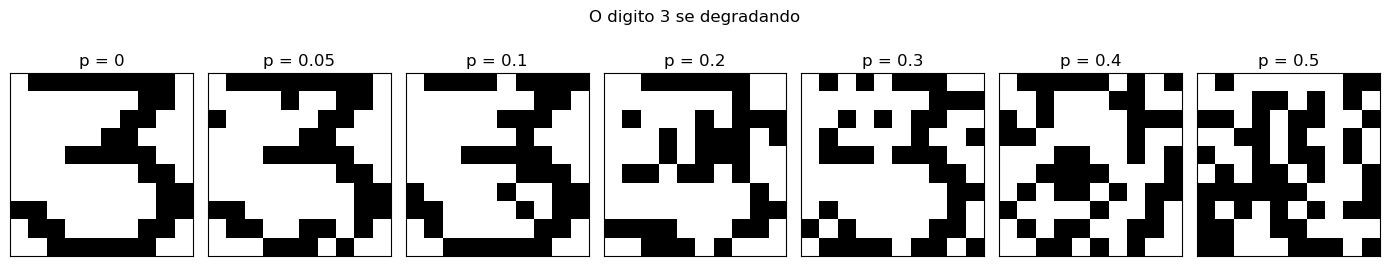

In [7]:
rng = np.random.default_rng(7)
niveis = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
fig, eixos = plt.subplots(1, len(niveis), figsize=(2*len(niveis), 2.6))
for p, ax in zip(niveis, eixos):
    ax.imshow(para_imagem(adicionar_ruido(X[3], p, rng)), cmap="gray_r",
              vmin=-1, vmax=1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"p = {p:g}")
fig.suptitle("O digito 3 se degradando", y=1.04)
fig.tight_layout(); plt.show()

In [8]:
ps = np.arange(0.0, 0.55, 0.05)
accs = [testar_com_ruido(rede, X, rotulos, p, repeticoes=300) * 100 for p in ps]

print(f"{'p':>6} | {'pixels trocados':>16} | {'acuracia':>9}")
print("-" * 38)
for p, a in zip(ps, accs):
    print(f"{p:>6.2f} | {int(p*100):>14} % | {a:>8.1f}%")

     p |  pixels trocados |  acuracia
--------------------------------------
  0.00 |              0 % |    100.0%
  0.05 |              5 % |     99.9%
  0.10 |             10 % |     99.4%
  0.15 |             15 % |     97.5%
  0.20 |             20 % |     92.8%
  0.25 |             25 % |     86.5%
  0.30 |             30 % |     77.1%
  0.35 |             35 % |     62.7%
  0.40 |             40 % |     44.1%
  0.45 |             45 % |     25.0%
  0.50 |             50 % |      9.8%


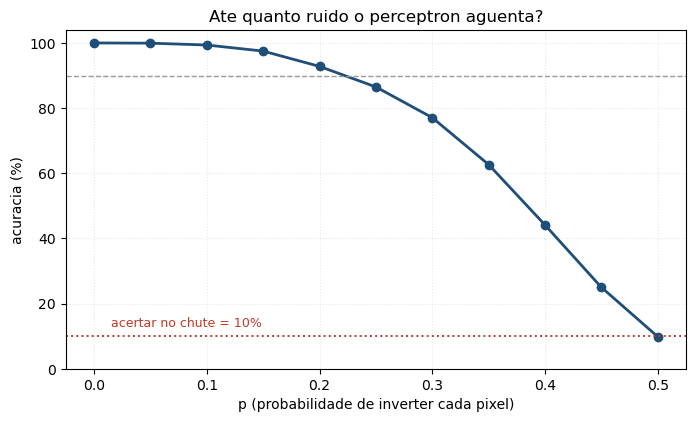

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(ps, accs, "o-", color="#1f4e79", lw=2, markersize=6)
ax.axhline(90, color="#999", ls="--", lw=1)
ax.axhline(10, color="#c0392b", ls=":", lw=1.4)
ax.text(0.015, 13, "acertar no chute = 10%", color="#c0392b", fontsize=9)
ax.set_xlabel("p (probabilidade de inverter cada pixel)")
ax.set_ylabel("acuracia (%)"); ax.set_ylim(0, 104)
ax.grid(alpha=0.3, ls=":")
ax.set_title("Ate quanto ruido o perceptron aguenta?")
plt.show()

### Três leituras

**A queda é suave, não abrupta.** Com 20% dos pixels trocados a acurácia ainda
é ~93%. Os 100 pixels contribuem de forma independente na soma, então as
inversões aleatórias **se cancelam** umas às outras. A rede não depende de
nenhum pixel em particular.

**O limite de 90% fica em $p \approx 0{,}22$** — cerca de 22 pixels dos 100
podem estar errados.

**Em $p = 0{,}5$ o desempenho é o do chute** (≈10%). Faz sentido: com metade
dos pixels invertida ao acaso, a imagem perde qualquer relação com o original.
Não há informação alguma para usar.

## 6. Demonstrações

Três demos interativas, no arquivo `demo.py`. **Abrem em janela separada.**

| # | demo | o que mostra |
|---|---|---|
| 1 | Treino passo a passo | os pesos se formando, uma época por clique |
| 2 | Ruído com slider | a rede acertando até quebrar |
| 3 | Desenhar e **ensinar** | você desenha, a rede classifica — e aprende se errar |

**No terminal** (jeito mais confiável para projetar):

```bash
python3 demo.py 1     # treino passo a passo
python3 demo.py 2     # ruido com slider
python3 demo.py 3     # desenhar o digito
```

### Legenda demo 3

O gráfico de barras mostra o $y\_in$ de cada neurônio. **A linha do zero é o
que importa** — um neurônio só reconhece quando fica acima dela.

| o que aparece | significado |
|---|---|
| uma barra acima de zero | resposta limpa (verde) |
| **nenhuma** barra acima de zero | a rede **não reconheceu nada** (laranja) |
| várias barras acima de zero | resposta ambígua (laranja) |

> Essa distinção resolve a maior fonte de confusão. Um rabisco qualquer produz
> dez valores **negativos**, e o "maior" deles é apenas o **menos ruim**.
> Chamar isso de resposta seria enganoso — a demo diz explicitamente que não
> houve reconhecimento.

## Conclusões

**Funciona, e é barato.** 1.010 parâmetros, 4 épocas, treino instantâneo.
O menor modelo comparado por Sehta et al. (2024) tem 118.282 parâmetros —
mais de 100 vezes mais.

**Aguenta ruído melhor do que se espera.** Mantém 90% de acerto com ~22 dos
100 pixels invertidos.

**Mas o mérito é do problema, não do algoritmo.** Aqui há um único exemplar
ideal por classe: dez pontos bem espaçados em $\mathbb{R}^{100}$ são
trivialmente separáveis por um hiperplano.

Com a variedade de caligrafias do MNIST, cada classe vira uma nuvem que invade
a das outras — e aí a camada única falha. É a limitação que Minsky e Papert
(1969) formalizaram e que levou às redes multicamadas.

## Referências

1. **N. Sehta, K. Saraf, A. Vinchi** (2024). Evaluation of Classifiers Based on
   Neural Network for Handwritten Digit Recognition. *ACROSET*, IEEE.
   DOI: 10.1109/ACROSET62108.2024.10743433 — *artigo de base*
2. **F. Rosenblatt** (1958). The perceptron: a probabilistic model for
   information storage and organization in the brain.
   *Psychological Review*, 65(6), 386–408.
3. **L. V. Fausett** (1994). *Fundamentals of Neural Networks*. Prentice Hall.
4. **A. B. J. Novikoff** (1962). On convergence proofs for perceptrons.
   *Symp. Math. Theory of Automata*, 12, 615–622.
5. **M. Minsky, S. Papert** (1969). *Perceptrons*. MIT Press.
6. **Y. LeCun, L. Bottou, Y. Bengio, P. Haffner** (1998). Gradient-based
   learning applied to document recognition. *Proc. IEEE*, 86(11), 2278–2324.